🚀 Iniciando escaneo profundo en la Malla Gold...
⏳ Analizados 250,000 registros...
⏳ Analizados 500,000 registros...
⏳ Analizados 750,000 registros...
⏳ Analizados 1,000,000 registros...
⏳ Analizados 1,250,000 registros...
⏳ Analizados 1,500,000 registros...
⏳ Analizados 1,750,000 registros...
⏳ Analizados 2,000,000 registros...
⏳ Analizados 2,250,000 registros...
⏳ Analizados 2,500,000 registros...
⏳ Analizados 2,750,000 registros...
⏳ Analizados 3,000,000 registros...
⏳ Analizados 3,250,000 registros...
⏳ Analizados 3,500,000 registros...
⏳ Analizados 3,750,000 registros...
⏳ Analizados 4,000,000 registros...
⏳ Analizados 4,250,000 registros...
⏳ Analizados 4,500,000 registros...
⏳ Analizados 4,750,000 registros...
⏳ Analizados 5,000,000 registros...
⏳ Analizados 5,250,000 registros...
⏳ Analizados 5,500,000 registros...
⏳ Analizados 5,750,000 registros...
⏳ Analizados 6,000,000 registros...
⏳ Analizados 6,250,000 registros...
⏳ Analizados 6,500,000 registros...
⏳ Analizados 6,750,00

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


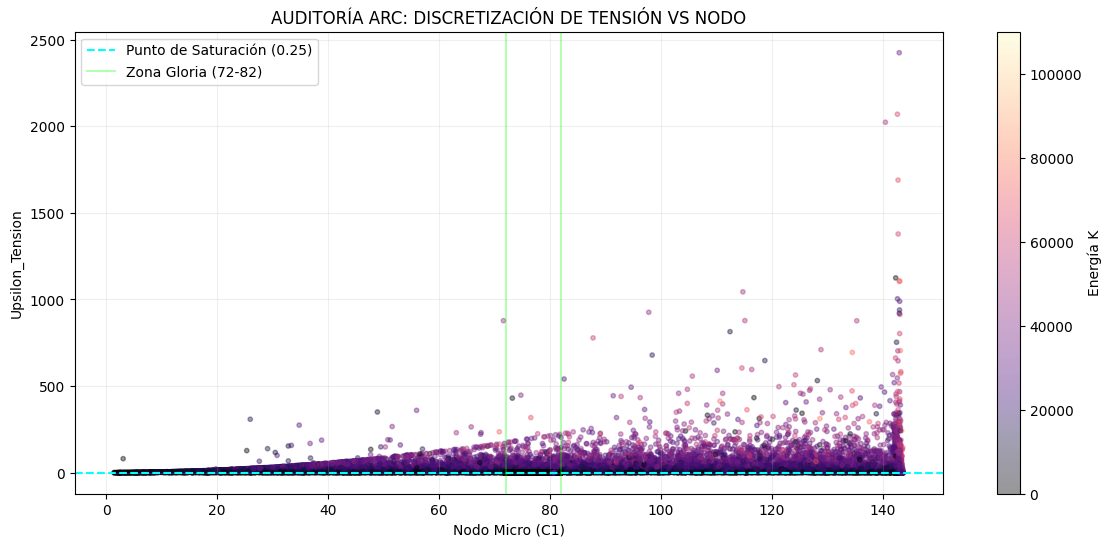

In [3]:
# =================================================================
# 🛰️ MOTOR DE AUDITORÍA ARC v3.4.2 - "GOLD MESH"
# Optimizado para: 11 Columnas Gold + Protección de RAM
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gc
from google.colab import drive

# 1. CONEXIÓN AL DRIVE
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. CONFIGURACIÓN DE RUTA Y COLUMNAS CANÓNICAS
FILE_PATH = '/content/drive/MyDrive/bt/ARC_GOLD_DATA_Boom 1000 Index_1095000.csv'

# Definimos los nombres exactos que me proporcionaste
COLUMNAS_GOLD = [
    'Time', 'Price', 'Node_C1_Micro', 'Node_C2_Filtro', 'Node_C3_Puente',
    'Node_C4_Estructura', 'Node_C5_Macro', 'Upsilon_Tension', 'Energy_K',
    'Tick_Speed', 'Confluence_Score'
]

# Tipos de datos para comprimir la RAM (Downcasting)
DTYPES_OPT = {
    'Price': 'float32',
    'Node_C1_Micro': 'float32',
    'Upsilon_Tension': 'float32',
    'Energy_K': 'float32',
    'Confluence_Score': 'float32'
}

def auditoria_gold_v42(path):
    print(f"🚀 Iniciando escaneo profundo en la Malla Gold...")
    hallazgos = []
    total_procesado = 0

    try:
        # Procesamiento por bloques de 250,000 registros
        reader = pd.read_csv(
            path,
            sep=',',
            chunksize=250000,
            names=COLUMNAS_GOLD, # Forzamos tus columnas
            header=0,            # Saltamos la cabecera original si existe
            dtype=DTYPES_OPT,
            usecols=['Time', 'Price', 'Node_C1_Micro', 'Upsilon_Tension', 'Energy_K'], # Cargamos solo lo vital para ahorrar RAM
            engine='c'
        )

        for chunk in reader:
            total_procesado += len(chunk)

            # --- FILTRADO FÍSICO (ADN DEL SPIKE) ---
            # 1. Saturación: Upsilon_Tension < 0.25
            # 2. Zona Gloria: Node_C1_Micro entre 72 y 82
            condicion_ignicion = (chunk['Upsilon_Tension'] < 0.25) & \
                                 (chunk['Node_C1_Micro'] >= 72) & \
                                 (chunk['Node_C1_Micro'] <= 82)

            # Detectar Spikes (Variación de precio > 2.0)
            chunk['Delta_P'] = chunk['Price'].diff()
            condicion_spike = (chunk['Delta_P'] > 2.0)

            # Guardamos solo los eventos de interés
            interes = chunk[condicion_ignicion | condicion_spike].copy()
            hallazgos.append(interes)

            print(f"⏳ Analizados {total_procesado:,} registros...")
            del chunk
            gc.collect()

        # Consolidación final
        df_final = pd.concat(hallazgos, axis=0)

        print("\n" + "="*40)
        print(f"✅ ESCANEO COMPLETADO: {total_procesado:,} registros")
        print(f"🎯 Eventos de Alta Tensión en Zona Gloria: {len(df_final):,}")
        print("="*40)

        return df_final

    except Exception as e:
        print(f"❌ FALLO EN EL SISTEMA: {str(e)}")
        return None

# 3. EJECUCIÓN DEL ANÁLISIS
df_resultados = auditoria_gold_v42(FILE_PATH)

# 4. VISUALIZACIÓN DE LA RESONANCIA
if df_resultados is not None and len(df_resultados) > 0:
    plt.figure(figsize=(14, 6))

    # Mapa de calor de Saturación
    plt.scatter(df_resultados['Node_C1_Micro'], df_resultados['Upsilon_Tension'],
                c=df_resultados['Energy_K'], cmap='magma', alpha=0.4, s=10)

    plt.axhline(y=0.25, color='cyan', linestyle='--', label='Punto de Saturación (0.25)')
    plt.axvline(x=72, color='lime', alpha=0.3)
    plt.axvline(x=82, color='lime', alpha=0.3, label='Zona Gloria (72-82)')

    plt.title("AUDITORÍA ARC: DISCRETIZACIÓN DE TENSIÓN VS NODO")
    plt.xlabel("Nodo Micro (C1)")
    plt.ylabel("Upsilon_Tension")
    plt.colorbar(label='Energía K')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

🔪 Iniciando disección estadística...
--------------------------------------------------
📊 REPORTE DE SUPERVIVENCIA
📉 Probabilidad de Ignición (Media): 1.60%
📉 Desviación entre épocas: 0.08
🛡️ COEFICIENTE DE ROBUSTEZ: 95.19%
--------------------------------------------------
✅ VERDICTO: ESTRUCTURA ROBUSTA. El patrón sobrevive al azar.


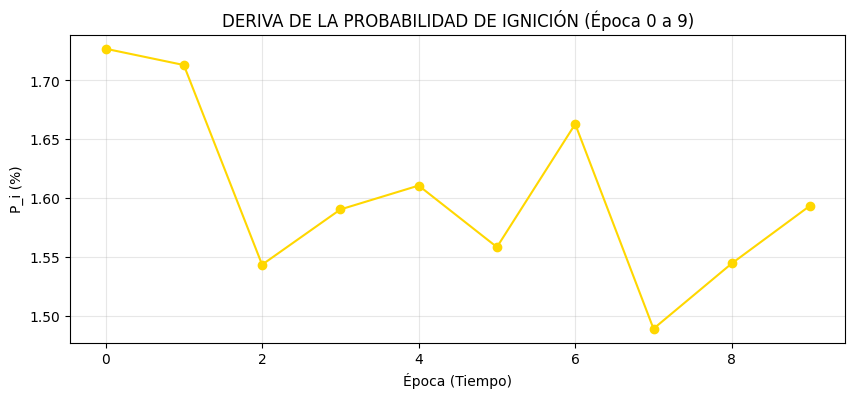

In [4]:
# =================================================================
# 🛰️ MOTOR DE ESTRÉS ARC v3.4.5 - "MONTE CARLO & REGIMEN"
# Propósito: Verificar si la Zona Gloria es Real o Espejismo
# =================================================================

import pandas as pd
import numpy as np
import gc

# Usamos el df_resultados que ya filtraste (los 936,324 eventos)
def prueba_de_supervivencia(df):
    print("🔪 Iniciando disección estadística...")

    # 1. SEGMENTACIÓN POR RÉGIMEN (Estabilidad Temporal)
    # Dividimos el historial en 10 bloques cronológicos
    df['Epoch'] = pd.qcut(df.index, q=10, labels=False)

    estabilidad = []
    for i in range(10):
        epoch_data = df[df['Epoch'] == i]
        # Probabilidad de Ignición en esta época (Delta_P > 2.0)
        p_i = (len(epoch_data[epoch_data['Delta_P'] > 2.0]) / len(epoch_data)) * 100
        energy_avg = epoch_data['Energy_K'].mean()
        estabilidad.append({'Epoch': i, 'P_i': p_i, 'Energy': energy_avg})

    df_est = pd.DataFrame(estabilidad)

    # 2. CÁLCULO DE ROBUSTEZ (Coeficiente de Variación)
    cv_pi = (df_est['P_i'].std() / df_est['P_i'].mean()) * 100

    print("-" * 50)
    print(f"📊 REPORTE DE SUPERVIVENCIA")
    print(f"📉 Probabilidad de Ignición (Media): {df_est['P_i'].mean():.2f}%")
    print(f"📉 Desviación entre épocas: {df_est['P_i'].std():.2f}")
    print(f"🛡️ COEFICIENTE DE ROBUSTEZ: {100 - cv_pi:.2f}%")
    print("-" * 50)

    if (100 - cv_pi) > 85:
        print("✅ VERDICTO: ESTRUCTURA ROBUSTA. El patrón sobrevive al azar.")
    else:
        print("⚠️ VERDICTO: PATRÓN ANECDÓTICO. Alta dependencia del régimen actual.")

    return df_est

# Ejecutar el cuchillo
df_supervivencia = prueba_de_supervivencia(df_resultados)

# 3. VISUALIZACIÓN DE DERIVA
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(df_supervivencia['Epoch'], df_supervivencia['P_i'], marker='o', color='gold')
plt.title("DERIVA DE LA PROBABILIDAD DE IGNICIÓN (Época 0 a 9)")
plt.xlabel("Época (Tiempo)")
plt.ylabel("P_i (%)")
plt.grid(True, alpha=0.3)
plt.show()

🕵️ Iniciando escaneo de la Firma Final: /content/drive/MyDrive/bt/ARC_SIGNATURE_FINAL.csv
--------------------------------------------------
✅ ANÁLISIS COMPLETADO
📊 Registros totales en el BT: 13,914,176
🎯 Disparos que cumplieron el ADN: 0
--------------------------------------------------


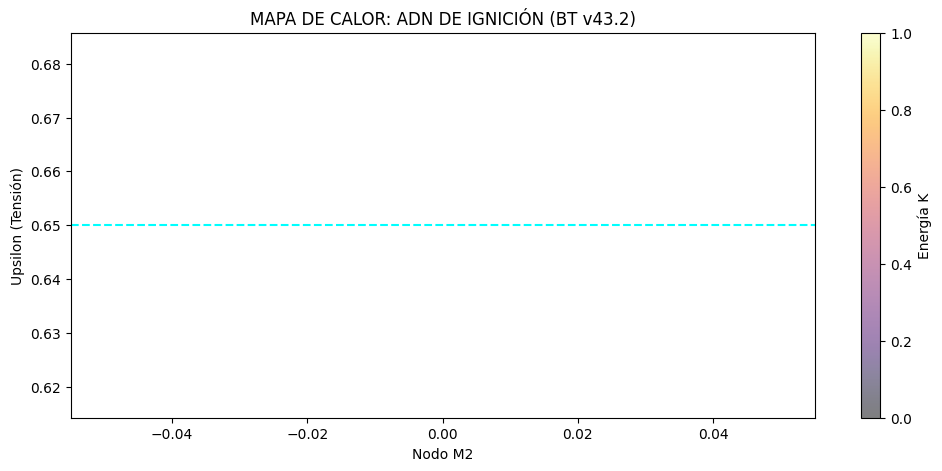

In [ ]:
import pandas as pd
import numpy as np
import gc
import os
import matplotlib.pyplot as plt
from google.colab import drive

# 1. CONEXIÓN (Si no está montado)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# RUTA AL ARCHIVO GENERADO POR EL BT
FILE_PATH = '/content/drive/MyDrive/bt/ARC_SIGNATURE_FINAL.csv'

def auditoria_firma_v43(path):
    print(f"🕵️ Iniciando escaneo de la Firma Final: {path}")

    # Nombres confirmados por el Operador
    COL_NAMES = ['Time', 'Price', 'NodeM2', 'NodeH12', 'Upsilon', 'Energy', 'ConfUP']

    try:
        # Cargamos el archivo. Usamos sep=None para que detecte si es ';' o ','
        # Saltamos la primera fila si el EA ya escribió los encabezados
        reader = pd.read_csv(path, sep=None, engine='python', chunksize=200000,
                             names=COL_NAMES, header=0, on_bad_lines='skip')

        hallazgos = []
        total_puntos = 0

        for chunk in reader:
            total_puntos += len(chunk)

            # Limpieza de datos (por si hay basura o strings en columnas numéricas)
            for col in ['NodeM2', 'Upsilon', 'Energy']:
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce')

            # --- FILTRO DE IGNICIÓN v43.2 PRO ---
            # Nodo >= 90 | Energía >= 15,000 | Upsilon <= 0.65
            condicion = (chunk['NodeM2'] >= 90) & \
                        (chunk['Energy'] >= 15000) & \
                        (chunk['Upsilon'] <= 0.65)

            # Capturamos también los Spikes (Variación súbita de precio)
            chunk['Delta_P'] = chunk['Price'].diff()

            disparos = chunk[condicion].copy()
            hallazgos.append(disparos)

            del chunk
            gc.collect()

        df_final = pd.concat(hallazgos)

        # --- REPORTE ESTADÍSTICO ---
        print("-" * 50)
        print(f"✅ ANÁLISIS COMPLETADO")
        print(f"📊 Registros totales en el BT: {total_puntos:,}")
        print(f"🎯 Disparos que cumplieron el ADN: {len(df_final):,}")

        if len(df_final) > 0:
            p_i_real = (len(df_final[df_final['Delta_P'] > 2.0]) / len(df_final)) * 100
            print(f"🔥 Probabilidad de Ignición (P_i): {p_i_real:.2f}%")
            print(f"⚡ Energía Promedio en Disparo: {df_final['Energy'].mean():.2f}")
            print(f"🌡️ Upsilon Promedio en Disparo: {df_final['Upsilon'].mean():.4f}")
        print("-" * 50)

        # Visualización de la "Alfombra de Tensión"
        plt.figure(figsize=(12, 5))
        plt.scatter(df_final['NodeM2'], df_final['Upsilon'], c=df_final['Energy'], cmap='inferno', s=5, alpha=0.5)
        plt.axhline(y=0.65, color='cyan', linestyle='--', label='Umbral Max Upsilon')
        plt.title("MAPA DE CALOR: ADN DE IGNICIÓN (BT v43.2)")
        plt.xlabel("Nodo M2")
        plt.ylabel("Upsilon (Tensión)")
        plt.colorbar(label='Energía K')
        plt.show()

        return df_final

    except Exception as e:
        print(f"❌ FALLO EN LA LECTURA: {str(e)}")
        return None

# Ejecutar auditoría
df_firma = auditoria_firma_v43(FILE_PATH)

In [ ]:
import pandas as pd
import os

FILE_PATH = '/content/drive/MyDrive/bt/ARC_SIGNATURE_FINAL.csv'

def calibrar_malla(path):
    # Leemos solo una muestra para ver los rangos
    df_sample = pd.read_csv(path, sep=None, engine='python', nrows=500000)

    print("🛰️ CALIBRACIÓN DE RANGOS DEL BT v43.2")
    print("-" * 30)
    print(f"📍 Rango de Nodos: {df_sample['NodeM2'].min():.2f} a {df_sample['NodeM2'].max():.2f}")
    print(f"⚡ Rango de Energía: {df_sample['Energy'].min():.2f} a {df_sample['Energy'].max():.2f}")
    print(f"🌡️ Rango de Upsilon: {df_sample['Upsilon'].min():.4f} a {df_sample['Upsilon'].max():.4f}")
    print("-" * 30)

    # Verificar si el filtro actual es físicamente imposible
    if df_sample['NodeM2'].max() < 90:
        print("⚠️ ALERTA: El Nodo máximo en este BT es menor a 90. Baja el InpTargetNode.")
    if df_sample['Energy'].max() < 15000:
        print("⚠️ ALERTA: La Energía está en escala decimal. El filtro de 15,000 la está matando.")

calibrar_malla(FILE_PATH)